# Point Source Injector

<div class="alert alert-block alert-info">

The source injector can produce mock simulated data independent of the MEGAlib software.

Standard data simulation requires the users to install and use MEGAlib to convolve the source model with the detector effects to generate data. The source injector utilizes the response generated by intensive simulation, which contains the statistical detector effects. With the source injector, you can convolve response, source model, and orientation to gain the mock data quickly.

The advantages of using the source injector include:

- No need to install and use MEGAlib
- Get the data much faster than the standard simulation pipeline
- The generated data are in the format that can be used for spectral fitting, localization, imaging, etc.

The disadvantages are:

- The data are binned based on the binning of the response, which means that you lost the unbinned event distribution as you will get from the MEGAlib pipeline.
- If the response is coarse, the data you generated might not be precise.


In [1]:
%%capture
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import astropy.units as u
from astropy.coordinates import SkyCoord

from astromodels.core.polarization import LinearPolarization

from threeML import *

from histpy import Histogram
from mhealpy import HealpixMap

from cosipy import BinnedData, SpacecraftHistory, SourceInjector
from cosipy.event_selection import GoodTimeInterval
from cosipy.polarization.conventions import IAUPolarizationConvention
from cosipy.polarization.polarization_angle import PolarizationAngle
from cosipy.threeml.custom_functions import SpecFromDat
from cosipy.util import fetch_wasabi_file

%matplotlib inline


## Get the data

The data can be downloaded by running the cells below. Each respective cell also gives the wasabi file path and file size.


In [2]:
%%capture
response_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"

In [3]:
%%capture
orientation_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"

## NGC 1068

### Thermal

In [4]:
source = "NGC1068"
model = "cpl"
K_inj = 3.1e-1 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.92

spectrum_inj_1068 = Cutoff_powerlaw()

spectrum_inj_1068.K.value = K_inj.value
spectrum_inj_1068.piv.value = piv_inj.value
spectrum_inj_1068.xc.value = xc_inj.value
spectrum_inj_1068.index.value = index_inj

spectrum_inj_1068.K.unit = K_inj.unit
spectrum_inj_1068.piv.unit = piv_inj.unit
spectrum_inj_1068.xc.unit = xc_inj.unit

### Non-thermal

In [6]:
# K_inj = 0.1*((3.1e-1)*100) / u.cm / u.cm / u.s / u.keV
K_inj = 0.15*spectrum_inj_1068.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -3.8

spectrum_inj_1068_PL = Powerlaw()

spectrum_inj_1068_PL.K.value = K_inj.value
spectrum_inj_1068_PL.piv.value = piv_inj.value
spectrum_inj_1068_PL.index.value = index_inj

spectrum_inj_1068_PL.K.unit = K_inj.unit
spectrum_inj_1068_PL.piv.unit = piv_inj.unit

l = 172.104  # Galactic longitude, degrees
b = -51.934  # Galactic latitude, degrees

In [7]:
# Define the coordinate of the point source
source_coord = SkyCoord(l=l, b=b, frame="galactic", unit="deg")

# define the NGC1068 point source
point_source = PointSource(
    source, l=source_coord.l.deg, b=source_coord.b.deg, spectral_shape=spectrum_inj_1068
)
# # define the NGC1068 point source
# point_source = PointSource(
#     "NGC1068", l=source_coord.l.deg, b=source_coord.b.deg, spectral_shape=(spectrum_inj_1068 + spectrum_inj_1068_PL)
# )

# define the model. The model can contain multiple point sources.
model = Model(point_source)

### Read orientation file


In [8]:
# Read the three-month orientation and retain only intervals where NGC 1068
# is within 60 degrees of the spacecraft boresight.
ori = SpacecraftHistory.open(orientation_path)
fov_cut = 60 * u.deg

source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    ori,
    fov_cut,
    earth_occ=False,
)
ori_fov60 = ori.apply_gti(source_gti)

print(f"FOV cut: {fov_cut.to_value(u.deg):.0f} deg")
print(f"GTI intervals: {len(source_gti):,}")
print(f"Selected livetime: {ori_fov60.cumulative_livetime().to_value(u.s):,.1f} s")

FOV cut: 60 deg
GTI intervals: 1,300
Selected livetime: 2,546,115.0 s


### Apply the NGC 1068 FOV cut to the background


In [ ]:
# %%time

# unbinned_background_file = Path(
#     "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Background/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits"
# )
# binning_config = Path(
#     "/Users/parshadkp/Software/cosipy/docs/tutorials/source_injector/inputs.yaml"
# )
# background_output_file = unbinned_background_file.with_name(
#     "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
#     "NGC1068_60deg_fov_cut.hdf5"
# )

# for path in (unbinned_background_file, binning_config):
#     if not path.exists():
#         raise FileNotFoundError(path)

# background_binner = BinnedData(str(binning_config))
# background_binner.cosi_dataset = background_binner.get_dict(
#     str(unbinned_background_file)
# )
# orientation_edges_unix = ori.obstime.unix
# n_orientation_intervals = len(ori.livetime)

# # Mark the original orientation intervals contained in the merged GTIs.
# keep_interval = np.zeros(n_orientation_intervals, dtype=bool)
# for gti_start, gti_stop in source_gti:
#     start_index = np.searchsorted(orientation_edges_unix, gti_start.unix, side="left")
#     stop_index = np.searchsorted(orientation_edges_unix, gti_stop.unix, side="left")
#     keep_interval[start_index:stop_index] = True

# background_times = background_binner.cosi_dataset["TimeTags"]
# background_fov_mask = np.zeros(len(background_times), dtype=bool)
# chunk_size = 5_000_000
# for start in range(0, len(background_times), chunk_size):
#     stop = min(start + chunk_size, len(background_times))
#     event_interval_index = np.searchsorted(
#         orientation_edges_unix, background_times[start:stop], side="right"
#     ) - 1
#     valid_event_time = (
#         (event_interval_index >= 0)
#         & (event_interval_index < n_orientation_intervals)
#     )
#     chunk_mask = np.zeros(stop - start, dtype=bool)
#     chunk_mask[valid_event_time] = keep_interval[
#         event_interval_index[valid_event_time]
#     ]
#     background_fov_mask[start:stop] = chunk_mask

#     print(f"Background FOV selection: {stop / len(background_times):.0%}", end="\r")
# print()

# # Replace one column at a time to avoid retaining a second full dataset.
# for key in list(background_binner.cosi_dataset):
#     background_binner.cosi_dataset[key] = (
#         background_binner.cosi_dataset[key][background_fov_mask]
#     )
# selected_background_times = background_binner.cosi_dataset["TimeTags"]
# if len(selected_background_times) == 0:
#     raise RuntimeError("The NGC 1068 FOV cut selected no background events.")

# background_binner.tmin = float(np.min(selected_background_times))
# background_binner.tmax = float(np.max(selected_background_times))
# background_binner.get_binned_data(
#     make_binning_plots=False,
#     show_plots=False,
# )
# background_binner.binned_data.write(background_output_file, overwrite=True)

# print(f"Selected background events: {len(selected_background_times):,}")
# print(f"Wrote: {background_output_file}")

Background FOV selection: 100%


fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking


Selected background events: 63,393,923
Wrote: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Background/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC1068_60deg_fov_cut.hdf5
CPU times: user 1min 36s, sys: 2min 14s, total: 3min 51s
Wall time: 9min 45s


### Inject and save cutoff-energy histograms


In [9]:
# Define an injector by the response
injector = SourceInjector(response_path=response_path)

In [10]:
%%time

output_dir = Path("/Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models")
output_dir.mkdir(parents=True, exist_ok=True)

cutoff_energies_keV = np.arange(50, 201, 25)
injected_histograms = {}

for cutoff_keV in cutoff_energies_keV:
    spectrum_inj_1068.xc.value = float(cutoff_keV)

    file_path = output_dir / (
        f"{source}_ec_{cutoff_keV}_DC4_COSI_cpl_"
        f"{int(fov_cut.to_value(u.deg))}_fovCut.hdf5"
    )

    # SourceInjector does not overwrite existing files.
    if file_path.exists():
        file_path.unlink()

    injected_histograms[int(cutoff_keV)] = injector.inject_model(
        model=model,
        orientation=ori_fov60,
        make_spectrum_plot=False,
        fluctuate=False,
        data_save_path=file_path,
        earth_occ=True,
    )
    print(f"Wrote: {file_path}")

print(f"Created {len(injected_histograms)} cutoff-energy histograms.")

Wrote: /Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models/NGC1068_ec_50_DC4_COSI_cpl_60_fovCut.hdf5
Wrote: /Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models/NGC1068_ec_75_DC4_COSI_cpl_60_fovCut.hdf5
Wrote: /Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models/NGC1068_ec_100_DC4_COSI_cpl_60_fovCut.hdf5
Wrote: /Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models/NGC1068_ec_125_DC4_COSI_cpl_60_fovCut.hdf5
Wrote: /Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models/NGC1068_ec_150_DC4_COSI_cpl_60_fovCut.hdf5
Wrote: /Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models/NGC1068_ec_175_DC4_COSI_cpl_60_fovCut.hdf5
Wrote: /Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models/NGC1068_ec_200_DC4_COSI_cpl_60_fovCut.hdf5
Created 7 cutoff-energy histograms.
CPU times: user 45.6 s, sys: 648 ms, total: 46.2 s
Wall time: 48 s


E_c =  50 keV: 0.963 sigma
E_c =  75 keV: 2.893 sigma
E_c = 100 keV: 5.239 sigma
E_c = 125 keV: 7.729 sigma
E_c = 150 keV: 10.188 sigma
E_c = 175 keV: 12.496 sigma
E_c = 200 keV: 14.644 sigma


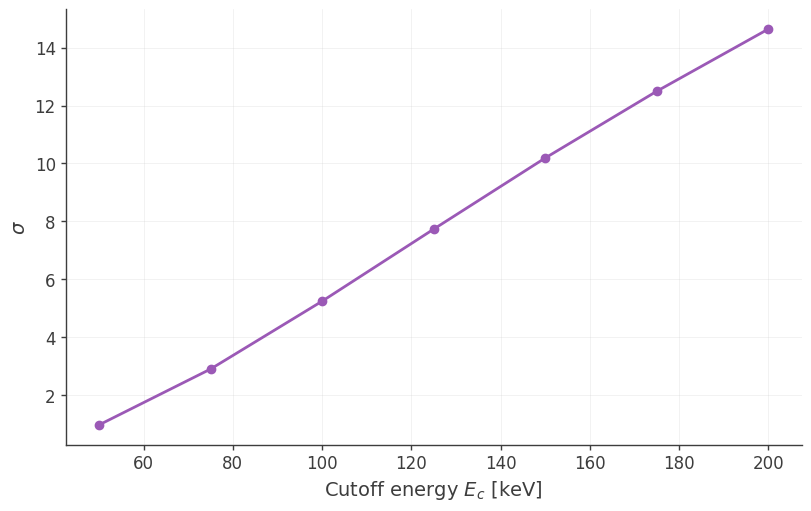

In [18]:
# Calculate S / sqrt(S + B) using the NGC 1068 60-degree-cut background.
background_file = background_output_file
if not background_file.exists():
    raise FileNotFoundError(background_file)


def histogram_counts(histogram):
    total = histogram.contents.sum()
    if hasattr(total, "compute"):
        total = total.compute()
    if hasattr(total, "todense"):
        total = total.todense()
    if hasattr(total, "value"):
        total = total.value
    return float(np.asarray(total).item())


background_histogram = Histogram.open(background_file)
background_counts = histogram_counts(background_histogram)
significance_by_cutoff = {}

for cutoff_keV, source_histogram in sorted(injected_histograms.items()):
    source_counts = histogram_counts(source_histogram)
    significance = source_counts / np.sqrt(source_counts + background_counts)
    significance_by_cutoff[cutoff_keV] = significance
    print(f"E_c = {cutoff_keV:3d} keV: {significance:.3f} sigma")

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.plot(
    list(significance_by_cutoff),
    list(significance_by_cutoff.values()),
    "o-",
    lw=2,
)
ax.set_xlabel(r"Cutoff energy $E_c$ [keV]")
ax.set_ylabel(r"$\sigma$")
ax.grid(alpha=0.3)